/kaggle/input/datasets/kandeelai22/messy-e-commerce-sales-dataset/messy_ecommerce_sales_data.csv
Path to dataset files: /kaggle/input/datasets/kandeelai22/messy-e-commerce-sales-dataset
    ID  Customer_Name   Order_ID  Order_Date        Product  Category  \
0  100   Customer_100  ORD-41285  11/22/2024        Blender      Home   
2  102   Customer_102  ORD-84355  12/23/2024  Tennis Racket    Sports   
3  103   Customer_103  ORD-57811   3/19/2025        Science     Books   
4  104   Customer_104  ORD-93614  10/20/2025      Biography     Books   
5  105   Customer_105  ORD-22442  11/20/2024  Tennis Racket    Sports   

  Quantity   Price    Payment_Method      Status    Total  
0        3   38.00  Cash on Delivery     Shipped   114.00  
2        1  389.05            PayPal   Delivered   389.05  
3        5  233.92            PayPal  Processing  1169.60  
4        1  552.51  Cash on Delivery  Processing   552.51  
5        3  122.06  Cash on Delivery   Cancelled   366.18  
               

/tmp/ipykernel_17/611147208.py:37: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data['Order_Date']= pd.to_datetime(data['Order_Date'], errors= 'coerce'
/tmp/ipykernel_17/611147208.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sellings_per_m= data.groupby('month').size()
/tmp/ipykernel_17/611147208.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_per_month= data.groupby('month'

correlation between sales and devolutions 0.7544704019330846
Proportions on payment method Payment_Method
Bank Transfer       0.275355
Cash on Delivery    0.395792
Credit Card         0.154091
PayPal              0.174762
Name: Total, dtype: float64
Proportions of cash flow Payment_Method
Cash on Delivery    0.395792
Bank Transfer       0.275355
PayPal              0.174762
Credit Card         0.154091
Name: Total, dtype: float64
month
January      12079.106
February     25577.852
March         5675.860
April         1200.280
May           5986.610
June          7092.310
July          7961.644
August        3057.982
September     5471.680
October      17403.950
November     11408.410
December      6494.850
Name: new_total, dtype: float64


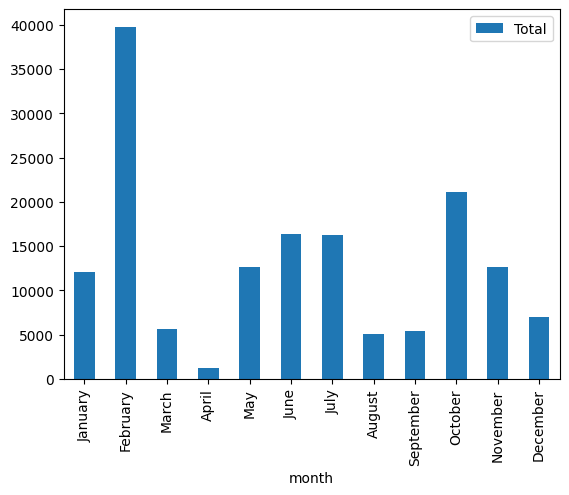

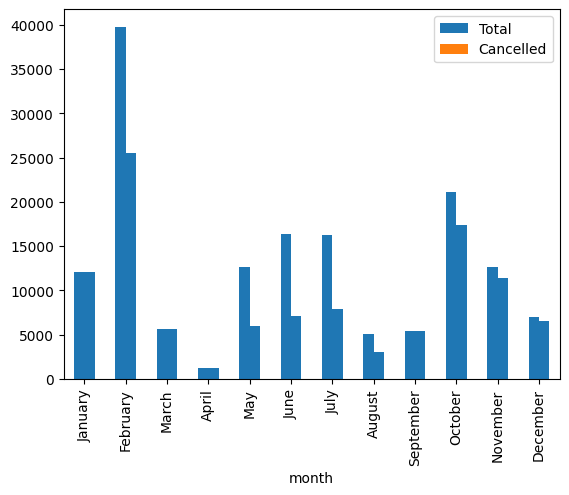

In [1]:


import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

path = kagglehub.dataset_download("kandeelai22/messy-e-commerce-sales-dataset")

print("Path to dataset files:", path)
for file in os.listdir(path):
    if file.endswith('.csv'):
        data = pd.read_csv(os.path.join(path, file))
        break
#Elimination of NA on price column
data['Price']= pd.to_numeric(data['Price'], errors= 'coerce')
data= data.dropna(subset= ['Price'])
data['Price']= data['Price'].astype(float)
print(data.head())
data['Total']= pd.to_numeric(data['Total'], errors= 'coerce')
data= data.dropna(subset= ['Total'])
data['Total']= data['Total'].astype(float)
data['Quantity']= pd.to_numeric(data['Quantity'], errors= 'coerce')
data= data.dropna(subset= ['Quantity'])
data['Quantity']= data['Quantity'].astype(float)
#Now we can start playing with the df
#Order of sells in products
sellings= data['Product'].value_counts()
result = data.groupby('Product')['Price'].agg(['count', 'first'])
print(result.sort_values('count', ascending= False))
print(result['count'].corr(result['first']))
#There is no co significant correlation betweeen the products and its prices.
data['Order_Date']= pd.to_datetime(data['Order_Date'], errors= 'coerce'
                                   , infer_datetime_format= True)
data['Quantity']= [abs(x) for x in data['Quantity']]
data['Total']= [abs(x) for x in data['Total']]
data['month']= data['Order_Date'].dt.month_name()
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

data['month'] = pd.Categorical(
    data['month'],
    categories=months_order,
    ordered=True
)
sellings_per_m= data.groupby('month').size()
print(sellings_per_m)
total_per_month= data.groupby('month')['Total'].sum()
print( 'Monthly Revenue ',
      total_per_month)
devolutions= data[data['Status'] == 'Cancelled'] \
    .groupby('month')['Total'].sum()
inprogress_sales= data[data['Status'] != 'Cancelled'] \
    .groupby('month')['Total'].sum()
revenue_per_year= data['Total'].sum()

print('Monthly Revenue after devolution'
      , devolutions)
print('best revenue days'
      , data.groupby('Order_Date')['Total'].sum().sort_values(ascending= False).head())
df_plot = total_per_month.reset_index()
df_plot.plot(x='month', y='Total', kind='bar')
df_total = total_per_month.rename('Total')
df_dev = devolutions.rename('Cancelled')

df_combined = pd.concat([df_total, df_dev], axis=1).fillna(0)
df_combined.plot(kind='bar')
print('correlation between sales and devolutions',
      devolutions.corr(inprogress_sales))
rev_method= data.groupby('Payment_Method')['Total'].sum()
meth_total= rev_method/revenue_per_year
print('Proportions on payment method'
      , 
      meth_total)
flow_method= data.groupby('Payment_Method')['Total'].sum().sort_values(ascending= False)
flow_proportion= flow_method/revenue_per_year
print('Proportions of cash flow',flow_proportion)
data['new_total'] = data['Total']
data.loc[data['Status'] == 'Cancelled', 'new_total'] *= -1
net_per_month = data.groupby('month', observed=False)['new_total'].sum().sort_index()
net_per_month.plot(kind='bar')
print(net_per_month)


In [2]:
print(path.head())

AttributeError: 'str' object has no attribute 'head'